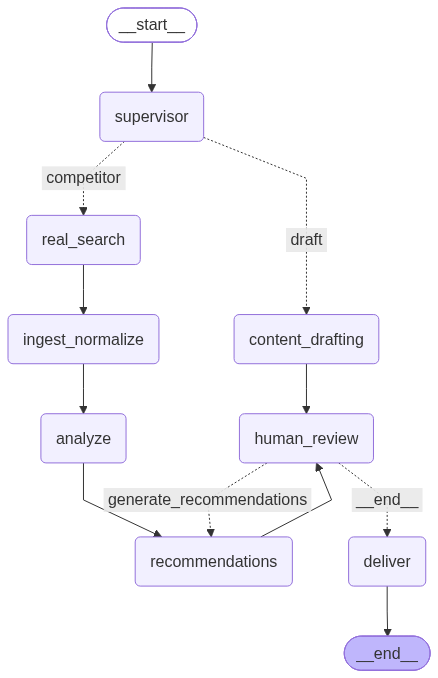

Graph compiled successfully.


In [4]:
import os

from dotenv import load_dotenv
from typing import Literal
from typing_extensions import TypedDict
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.postgres import PostgresSaver
from psycopg_pool import ConnectionPool
from email_utils import send_market_report_email

load_dotenv(override=True)

# Define Global State
class MarketState(TypedDict):
    messages: list
    task_type: str            # Routing determination: tender / competitor / gov / marketing / draft
    raw_data: list            # Collected raw data
    normalized_data: str      # Standardized data
    analysis_report: str      # Analysis and recommendations report
    draft_content: str        # Drafted content
    review_feedback: dict     # Human review feedback

model = ChatOllama(
    model="qwen2.5:7b",
    base_url="http://localhost:11434"
)
tavily_tool = TavilySearchResults(max_results=3)

# Define nodes

def supervisor_router_node(state: MarketState):
    """Supervisor / Router Node: Classify user intent into specific task types."""
    messages = state["messages"]

    system_prompt = SystemMessage(
        content="You are an expert AI supervisor for a market intelligence platform. "
                "Analyze the user's latest request and classify it into EXACTLY ONE of the following categories: "
                "'tender', 'competitor', 'gov', 'marketing', or 'draft'.\n"
                "- Use 'tender' if it relates to government procurement, bids, or tenders.\n"
                "- Use 'competitor' if it relates to rival companies, products, or competitors.\n"
                "- Use 'gov' if it relates to government policies, grants, or tax incentives.\n"
                "- Use 'marketing' if it relates to web analytics, traffic, or digital marketing.\n"
                "- Use 'draft' if the user wants to write or draft content.\n"
                "Return ONLY the category keyword."
    )

    response = model.invoke([system_prompt] + messages)
    content = response.content.strip().lower()

    if "tender" in content:
        task = "tender"
    elif "competitor" in content:
        task = "competitor"
    elif "gov" in content:
        task = "gov"
    elif "marketing" in content:
        task = "marketing"
    elif "draft" in content:
        task = "draft"
    else:
        task = "general"

    print(f"[Supervisor Routing] Intent classified as: [{task}]")
    return {"task_type": task}


def real_search_node(state: MarketState):
    """Search Node: Dynamic query generation and Tavily tool execution."""
    task_type = state.get("task_type", "general")

    query_map = {
        "tender": "latest government procurement tenders and contracts 2026",
        "competitor": "competitor analysis latest product launches market intelligence 2026",
        "gov": "government policy changes grants and tax incentives 2026",
        "marketing": "digital marketing trends web analytics growth strategies 2026",
        "general": "global tech market research and business opportunities 2026"
    }

    query = query_map.get(task_type, query_map["general"])
    print(f"Executing search node | Task: [{task_type}], Query: {query}")

    # Invoke Tavily tool
    search_results = tavily_tool.invoke({"query": query})

    # Format output
    formatted = [f"URL: {res.get('url')}\nContent: {res.get('content')}" for res in search_results]

    return {
        "raw_data": ["\n\n".join(formatted)]
    }

def ingest_and_normalize_node(state: MarketState):
    """Ingest & Normalize Node: Merge and clean raw data."""
    raws = state.get("raw_data", [])
    combined = "\n".join(raws)
    normalized = f"--- NORMALIZED MARKET INTELLIGENCE ---\n{combined}"
    return {"normalized_data": normalized}

def analyze_opportunities_node(state: MarketState):
    """Analyze opportunities and detect market trends."""
    data = state.get("normalized_data", "")
    system_prompt = SystemMessage(
        content=(
            "You are a senior market research analyst. Based on the provided intelligence data, "
            "write a comprehensive market trend and opportunity analysis report in professional English. "
            "Formatting requirements:\n"
            "1. Output ONLY the clean report text. Do not wrap it in extra JSON format or outer brackets.\n"
            "2. Use standard Markdown headings (#, ##) and ensure every paragraph and section is clearly separated with proper line breaks."
        )
    )
    response = model.invoke([system_prompt, HumanMessage(content=data)])
    return {"analysis_report": response.content}

def generate_recommendations_node(state: MarketState):
    """Generate strategic business recommendations."""
    current_report = state.get("analysis_report", "")
    system_prompt = SystemMessage(
        content="Review the analysis report below and generate a set of actionable, strategic business recommendations "
                "for our executive team in clear, professional English."
    )
    response = model.invoke([system_prompt, HumanMessage(content=current_report)])
    return {"analysis_report": f"{current_report}\n\n### Actionable Recommendations\n{response.content}"}

def content_drafting_node(state: MarketState):
    """Draft content based on user instructions."""
    system_prompt = SystemMessage(
        content="You are a professional content creator for B2B tech markets. "
                "Draft high-quality, engaging business content based on the user's request in English."
    )
    response = model.invoke([system_prompt] + state["messages"])
    return {"draft_content": response.content}

def human_review_node(state: MarketState):
    """Human Review / Approval Node: Core HITL mechanism."""
    target_content = state.get("analysis_report") or state.get("draft_content") or "No content available for review."

    # Trigger interrupt for human review
    user_action = interrupt({
        "status": "pending_review",
        "content": target_content
    })
    return {"review_feedback": user_action}

def deliver_node(state: MarketState):
    """Delivery Node: Extract report and deliver it to user with E-mail."""
    final_report = (
        state.get("analysis_report")
        or state.get("draft_content")
        or "No report content generated."
    )

    receiver_email = os.getenv("DEFAULT_RECEIVER_EMAIL", os.getenv("SENDER_EMAIL"))
    subject = "Weekly Market Analysis Report"

    print(f"--- Delivering to: {receiver_email} ---")

    success = send_market_report_email(
        receiver_email=receiver_email,
        subject=subject,
        markdown_content=final_report
    )

    delivery_status = "Successfully generated, approved, and delivered via email." if success else "Generated and approved, but email delivery failed."

    return {
        "messages": [AIMessage(content=delivery_status)]
    }


# router function
def route_from_supervisor(state: MarketState) -> Literal["tender", "competitor", "gov", "marketing", "draft"]:
    task = state.get("task_type")
    if task in ["tender", "competitor", "gov", "marketing"]:
        return task
    elif task == "draft":
        return "draft"
    return "marketing"

def route_after_review(state: MarketState) -> Literal["generate_recommendations", END]:
    feedback = state.get("review_feedback", {})
    if isinstance(feedback, dict) and feedback.get("action") == "needs_changes":
        return "generate_recommendations"
    return END

# add nodes and edge
builder = StateGraph(MarketState)

# Register nodes
builder.add_node("supervisor", supervisor_router_node)
builder.add_node("real_search", real_search_node)
builder.add_node("ingest_normalize", ingest_and_normalize_node)
builder.add_node("analyze", analyze_opportunities_node)
builder.add_node("recommendations", generate_recommendations_node)
builder.add_node("content_drafting", content_drafting_node)
builder.add_node("human_review", human_review_node)
builder.add_node("deliver", deliver_node)

# Set edges
builder.add_edge(START, "supervisor")

builder.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {
        "tender": "real_search",
        "competitor": "real_search",
        "gov": "real_search",
        "marketing": "real_search",
        "draft": "content_drafting"
    }
)

builder.add_edge("real_search", "ingest_normalize")
builder.add_edge("ingest_normalize", "analyze")
builder.add_edge("analyze", "recommendations")
builder.add_edge("recommendations", "human_review")
builder.add_edge("content_drafting", "human_review")

builder.add_conditional_edges(
    "human_review",
    route_after_review,
    {
        "generate_recommendations": "recommendations",
        END: "deliver"
    }
)

builder.add_edge("deliver", END)

# Compile graph with checkpointer for interrupt support
DB_URI = os.getenv("DB_URI")

connection_pool = ConnectionPool(
    conninfo=DB_URI,
    max_size=20,
    kwargs={"autocommit": True, "prepare_threshold": None}
)

checkpointer = PostgresSaver(connection_pool)
checkpointer.setup()

graph = builder.compile(checkpointer=checkpointer)

# Display graph
from IPython.display import display
display(graph)

print("Graph compiled successfully.")

In [8]:
from langgraph.types import Command

if __name__ == "__main__":
    config = {"configurable": {"thread_id": "market_agent_interactive_1"}}

    initial_input = {
        "messages": [HumanMessage(content="Please search for the latest government policies and tax incentives for tech startups in 2026.")]
    }

    print("=" * 50)
    print("Starting workflow...")
    print("=" * 50)

    try:
        graph.invoke(initial_input, config=config)
    except Exception:
        pass

    current_state = graph.get_state(config)

    print("\n" + "=" * 50)
    print("Workflow Paused: Human Review Required")
    print("=" * 50)

    for task in current_state.tasks:
        for interrupt_obj in task.interrupts:
            payload = getattr(interrupt_obj, "value", interrupt_obj)
            if isinstance(payload, dict):
                print("\n[Content Summary]:\n", payload.get("content")[:500] + "\n... (truncated) ...")
                # Uncomment this to get full content, remember to comment above
                #print("\n[Full Content]:\n", payload.get("content"))

    # Wait for human input
    print("\n" + "-" * 40)
    user_decision = input("Approve delivery? (yes/no): ").strip().lower()
    print("-" * 40)

    if user_decision == 'yes':
        resume_payload = {"action": "approved", "comment": "Looks good!"}
        print("Status: Approved")
    else:
        resume_payload = {"action": "needs_changes", "comment": "Please revise the recommendations."}
        print("Status: Changes requested")

    final_output = graph.invoke(Command(resume=resume_payload), config=config)
    print("\nWorkflow completed successfully.")

Starting workflow...
[Supervisor Routing] Intent classified as: [gov]
Executing search node | Task: [gov], Query: government policy changes grants and tax incentives 2026

Workflow Paused: Human Review Required

[Content Summary]:
 ### Market Trend and Opportunity Analysis Report

**Executive Summary:**
The transition of solar and HVAC incentives from a federal to a state-led framework in the United States, initiated by the passage of the "One Big Beautiful Bill" (OBBBA) in mid-2025, is expected to significantly reshape the landscape for residential and commercial clean energy investments. This report analyzes the evolving incentive structures, key state-level strategies, and strategic opportunities for businesses in the U
... (truncated) ...

----------------------------------------
----------------------------------------
Status: Approved
>>> Review approved! Pushing report to Dashboard/Email...

Workflow completed successfully.


In [7]:

#=========================================
# Thread memory in database test
# Click run to test if postgreSQL is available on your computer
#=========================================

# 1. First run with a fixed thread_id
config = {"configurable": {"thread_id": "test_thread_001"}}
initial_input = {"messages": [("user", "My competitor is Apple. Please help me do a comprehensive analysis.")]}

from rich import print as rprint
from rich.panel import Panel

print("--- Running Graph (First Iteration) ---")
for event in graph.stream(initial_input, config):
    for node_name, node_output in event.items():
        rprint(f"[bold cyan]Node Executed:[/] [green]{node_name}[/]")

        if isinstance(node_output, dict):
            for key, value in node_output.items():
                if isinstance(value, str) and len(value) > 100:
                    rprint(Panel(value, title=f"Output Key: {key}", border_style="blue"))
                else:
                    rprint(f"  [yellow]{key}:[/] {value}")
        else:
            rprint(f"  [yellow]Output:[/] {node_output}")

# 2. Verify state persistence from the database
print("\n--- Checking Saved State from Database ---")
saved_state = graph.get_state(config)
print(f"Next node: {saved_state.next}")
print(f"History count: {len(saved_state.values.get('messages', []))}")

# 3. Continue conversation using the same thread_id
print("\n--- Running Graph (Second Iteration) ---")
follow_up_input = {"messages": [("user", "What are the core competitive advantages of the competitor we just analyzed?")]}

for event in graph.stream(follow_up_input, config):
    print(event)

--- Running Graph (First Iteration) ---
[Supervisor Routing] Intent classified as: [competitor]


Node Executed: supervisor

task_type: competitor

Executing search node | Task: [competitor], Query: competitor analysis latest product launches market intelligence 2026


Node Executed: real_search

...

Node Executed: recommendations

╭────────────────────────────────────────── Output Key: analysis_report ──────────────────────────────────────────╮
│ # Market Trend and Opportunity Analysis Report                                                                  │
│                                                                                                                 │
│ ## Introduction                                                                                                 │
│                                                                                                                 │
│ The competitive intelligence (CI) market is rapidly evolving, driven by advancements in AI and data analytics.  │
│ This report provides a comprehensive analysis of key market trends and opportunities in the CI space, focusing  │
│ on tools and platforms like Contify, AlphaSense, and others.                                                    │
│                                                                                                                 │
│ ## Market Trends                                                                                                │
│                                                                                                                 │
│ ### 1. **Increased Adoption of AI and Machine Learning**                                                        │
│                                                                                                                 │
│ - **Driver**: The integration of AI and machine learning has significantly enhanced the accuracy and speed of   │
│ CI tools.                                                                                                       │
│ - **Impact**: These tools can process vast amounts of data, filter out irrelevant information, and provide      │
│ actionable insights in real-time, making them indispensable for businesses looking to stay ahead in competitive │
│ landscapes.                                                                                                     │
│                                                                                                                 │
│ ### 2. **Enhanced Collaboration and Sharing Features**                                                          │
│                                                                                                                 │
│ - **Driver**: The need for cross-departmental collaboration and knowledge sharing is driving the development of │
│ more robust collaboration tools.                                                                                │
│ - **Impact**: Tools like Contify offer APIs and integrations that facilitate seamless collaboration among       │
│ teams, enabling better decision-making and faster response times to market changes.                             │
│                                                                                                                 │
│ ### 3. **Focus on Customization and Flexibility**                                                               │
│                                                                                                                 │
│ - **Driver**: Businesses require tailored solutions that can be customized to fit specific needs and            │
│ industries.                                                                                                     │
│ - **Impact**: Customizable platforms like AlphaSense allow users to focus on specific areas of interest, such   │
│ as financial data or market trends, making the tools more relevant and effective for their unique requirements. │
│                                                                                                                 │
│ ### 4. **Real-Time Data and Insights**                                                                          │
│                                                       

Node Executed: __interrupt__

Output: (Interrupt(value={'status': 'pending_review', 'content': '# Market Trend and Opportunity Analysis 
Report\n\n## Introduction\n\nThe competitive intelligence (CI) market is rapidly evolving, driven by advancements 
in AI and data analytics. This report provides a comprehensive analysis of key market trends and opportunities in 
the CI space, focusing on tools and platforms like Contify, AlphaSense, and others.\n\n## Market Trends\n\n### 1. 
**Increased Adoption of AI and Machine Learning**\n\n- **Driver**: The integration of AI and machine learning has 
significantly enhanced the accuracy and speed of CI tools.\n- **Impact**: These tools can process vast amounts of 
data, filter out irrelevant information, and provide actionable insights in real-time, making them indispensable 
for businesses looking to stay ahead in competitive landscapes.\n\n### 2. **Enhanced Collaboration and Sharing 
Features**\n\n- **Driver**: The need for cross-departmental collaboration and knowledge sharing is driving the 
development of more robust collaboration tools.\n- **Impact**: Tools like Contify offer APIs and integrations that 
facilitate seamless collaboration among teams, enabling better decision-making and faster response times to market 
changes.\n\n### 3. **Focus on Customization and Flexibility**\n\n- **Driver**: Businesses require tailored 
solutions that can be customized to fit specific needs and industries.\n- **Impact**: Customizable platforms like 
AlphaSense allow users to focus on specific areas of interest, such as financial data or market trends, making the 
tools more relevant and effective for their unique requirements.\n\n### 4. **Real-Time Data and Insights**\n\n- 
**Driver**: The demand for real-time data and insights is increasing as businesses need to react quickly to market 
changes.\n- **Impact**: Real-time tracking of competitors, market trends, and customer insights helps businesses 
make informed decisions and stay agile in dynamic markets.\n\n## Opportunities\n\n### 1. **Integration with 
Existing Ecosystems**\n\n- **Opportunity**: Tools that can seamlessly integrate with existing business systems and 
workflows can gain significant traction.\n- **Implementation**: Platforms like Contify and AlphaSense should focus 
on providing APIs and integrations that allow easy integration with CRM, ERP, and other business tools.\n\n### 2. 
**Expansion into New Markets**\n\n- **Opportunity**: There is a growing need for CI tools in emerging markets, 
particularly in industries such as healthcare, technology, and retail.\n- **Implementation**: Companies should 
explore partnerships and local market insights to expand their reach into new territories.\n\n### 3. **Enhanced 
Data Privacy and Security Features**\n\n- **Opportunity**: With increasing concerns about data privacy and 
security, tools that offer robust security features can attract more users.\n- **Implementation**: Companies should
invest in advanced security protocols and transparent privacy policies to build trust with their customers.\n\n## 
Competitive Landscape\n\n### 1. **Contify**\n\n- **Strengths**: \n  - AI-native platform for real-time market and 
competitive intelligence.\n  - Strong AI search and analysis capabilities.\n  - Collaboration tools and shared 
intelligence layers.\n- **Weaknesses**:\n  - No access to proprietary data sources like broker research or expert 
calls.\n- **Opportunities**:\n  - Expand into more industries and markets.\n  - Develop partnerships with data 
providers to enhance data coverage.\n\n### 2. **AlphaSense**\n\n- **Strengths**:\n  - Focused on premium financial 
content and deep research workflows.\n  - AI-powered data collection and analysis.\n  - 360-degree competitor 
tracking.\n- **Weaknesses**:\n  - Limited to financial and strategic professionals.\n- **Opportunities**:\n  - 
Expand into broader business verticals.\n  - Develop more customizable reporting features.\n\n### 3. **Owler**\n\n-
**Strengths**:\n  - Affor


--- Checking Saved State from Database ---
Next node: ('human_review',)
History count: 1

--- Running Graph (Second Iteration) ---
[Supervisor Routing] Intent classified as: [competitor]
{'supervisor': {'task_type': 'competitor'}}
Executing search node | Task: [competitor], Query: competitor analysis latest product launches market intelligence 2026
{'real_search': {'raw_data': ['URL: https://www.contify.com/resources/blog/best-competitor-analysis-tools\nContent: 1. Contify: best suited for delivering real-time AI-powered market and competitive intelligence to help businesses track competitors, industry trends, and strategic insights.\n2. Crayon: best suited for enabling B2B revenue teams with real-time competitive intelligence and battlecards to win deals and respond effectively to competitors.\n3. AlphaSense: best suited for investment and corporate research teams to quickly extract insights from earnings calls, filings, and expert transcripts.\n4. SEMrush: best suited for marketing 